In [2]:
import os
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
import scipy
import datetime
import configparser

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator

import plt_helper

plt.style.use('latex_default.mplstyle')

"""Constants"""
# omega = 7.292*10**(-5)
g = 9.80665
Rd = 287.06
cp = 3.5 * Rd
Re = 6371229 # m (Radius of Earth for GRIB2 format - applies to ERA5 on ML)
p0 = 101325

cap=Rd/cp
capi=1/cap
capp=1.-cap # Cv/Cp
cappi=1./capp # Cp/Cv
wexnr=Rd/(cp-Rd) # Rd/Cv
compri=Rd/p0**cap
# th00=tt00*(pr00/pref00)**(-cap)
# rh00=pr00/(rg*tt00)

def tf(zeta):
    return zeta*zeta*zeta*(10.-15.*zeta+6.*zeta*zeta)
def tfd(zeta):
    return 30.*zeta*zeta*(1.-2.*zeta+zeta*zeta)

In [3]:
output_folder   = "./data/idealized_180616"
fpath = os.path.join("/export/data2/model/jawara","jawara_patagonia_180616.nc")

In [4]:
"""JAWARA background profile (average over one area)"""
ds_jawara = xr.open_dataset(fpath)

"""Reduce area"""
lats = slice(-52,-60)
# lats = slice(-44,-50)
lons = slice(278,286)
ds_jawara = ds_jawara.sel(latitude=lats, longitude=lons)

ds_jawara['rho'] = ds_jawara['p']**capp / (ds_jawara['th']*compri)
logth = np.log(ds_jawara['th'].values)
ds_jawara['N'] = (['time','level','latitude','longitude'], (g * np.gradient(logth, 400, axis=1))**(1/2))

"""Average and trim"""
ds_jawara = ds_jawara.mean(dim=["latitude","longitude"])

"""JAWARA background profile (select one point)"""
# ds_jawara = xr.open_dataset(fpath)

# """Select point"""
# # lon = 360-73
# # lat = -55.5
# lon = 360-67.5 # CORAL
# lat = -53.5 # CORAL
# ds_jawara = ds_jawara.sel(latitude=lat, longitude=lon, method="nearest")

# ds_jawara['rho'] = ds_jawara['p']**capp / (ds_jawara['th']*compri)
# logth = np.log(ds_jawara['th'].values)
# ds_jawara['N'] = (['time','level'], (g * np.gradient(logth, 400, axis=1))**(1/2))

# """Average and trim"""
# # ds['var'].values = scipy.ndimage.gaussian_filter(ds[var].values, sigma, axes=1)

dsm = ds_jawara.mean(dim="time")
dsm

<xarray.Dataset> Size: 22kB
Dimensions:  (level: 350)
Coordinates:
  * level    (level) int64 3kB 0 400 800 1200 ... 138400 138800 139200 139600
Data variables:
    u        (level) float64 3kB 7.518 11.16 12.66 ... -0.1191 0.02415 0.1674
    v        (level) float64 3kB -5.369 -6.857 -6.457 ... -3.629 -3.667 -3.705
    p        (level) float64 3kB 9.808e+04 9.337e+04 ... 0.000404 0.000394
    t        (level) float64 3kB 277.9 274.5 271.3 268.3 ... 596.1 599.9 603.7
    th       (level) float64 3kB 279.4 280.0 280.6 ... 1.565e+05 1.583e+05
    rho      (level) float64 3kB 1.234 1.189 1.145 ... 2.257e-09 2.191e-09
    N        (level) float64 3kB 0.006235 0.006706 0.007839 ... 0.0169 0.01685

In [28]:
def plot_wind(t, ds, folder, usmooth=None, vsmooth=None):
    fig, ax_wind = plt.subplots(1, 1, figsize=(6, 7))

    ut  = ds['u'].values
    vt  = ds['v'].values
    levels = ds['level'].values
    time = ds['time'][t].values

    """Wind profile plot"""
    lwl = 2
    lws = 1.5
    ax_wind.axvline(0, ls="-.", lw=1, color='grey')

    ax_wind.set_xlabel("(u,v) / m$\,$s$^{-1}$")
    ax_wind.set_ylabel("altitude z / km")
    ax_wind.set_xlim([-180, 180])
    ax_wind.set_ylim([0, 130])
    # ax_wind.xaxis.set_label_position('top')
    ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.tick_params(which='both', top=True, right=True, bottom=True, left=True, 
                        labelbottom=True, labeltop=False, color="grey")
    ax_wind.grid()

    ax_wind.text(0.97, 0.96, np.datetime_as_string(time, unit='m'), transform=ax_wind.transAxes, 
                 verticalalignment='top', horizontalalignment='right',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})
         

    # ax_wind.plot(ut[t,:], levels/1000, lw=lwl, ls='-',  color="black", label="u")
    # ax_wind.plot(vt[t,:], levels/1000, lw=lwl, ls='--', color="black", label="v")

    if usmooth is not None:
        ax_wind.plot(usmooth, levels[:len(usmooth)]/1000, lw=lws, ls='-',  color="royalblue", label="u_env")
        ax_wind.plot(vsmooth, levels[:len(usmooth)]/1000, lw=lws, ls='--', color="coral", label="v_env")
    ax_wind.legend(loc="lower left")

    """Save figure"""
    os.makedirs(folder, exist_ok=True)
    fig_name = 'wind_' + '{:02d}'.format(t) + '.png'
    fig.savefig(os.path.join(folder, fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight')

Array legth:  321 Max Alt:  128000


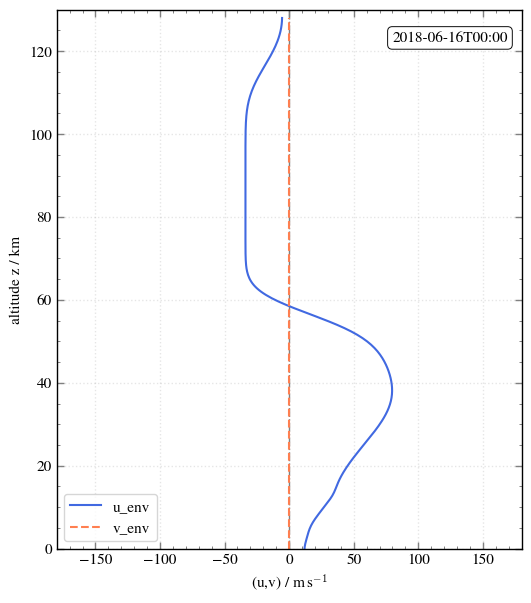

In [32]:
"""Pad wind profiles at upper boundary"""
# total = 320
icut = 135
npad = 185
icutv = 150
npadv = 170
vres = dsm['level'].values[1]-dsm['level'].values[0]
u  = np.concatenate((dsm['u'].values[:icut+1], dsm['u'].values[icut] * np.ones(npad)))
v  = np.concatenate((dsm['v'].values[:icutv+1], dsm['v'].values[icutv] * np.ones(npadv)))

levels = np.arange(0, len(v)*vres, vres)
levels_pad= levels[-npad:]
print("Array legth: ", len(levels), "Max Alt: ", levels[-1])


def tide_range(levels, zt0, zt1, zt2):
    r1 = np.where((levels>zt0) & (levels<=zt1), tf((levels-zt0)/(zt1-zt0)), 0)
    r2 = np.where((levels>zt1) & (levels<=zt2), 1-tf((levels-zt1)/(zt2-zt1)), 0)
    r3 = r1 + r2
    return r3

"""Base wind profile"""
zcut0 = levels[icut]
zcut1 = 60.e3

zcut2 = 105.e3
zcut3 = 128.e3
u01 = 30

# zcut2 = 65.e3
# zcut3 = 80.e3
# u01 = 80
zcut4 = 120.e3

u00 = 90 # depends on PNJ maximum

r00 = np.where((levels>zcut0), tf((levels-zcut0)/(zcut1-zcut0)), 0)
r00 = np.where(levels>zcut1, 1, r00)
r01 = np.where((levels>zcut2), tf((levels-zcut2)/(zcut3-zcut2)), 0)
u = u-u00*r00 + u01*r01

u = np.where((levels>zcut3), 0, u)

# u = np.where((levels>zcut3), 50, u)
# u = np.where((levels>zcut4), 0, u) 

u = scipy.ndimage.gaussian_filter(u, 1, axes=0) 

zcut0v = levels[icutv]
r00 = np.where((levels>zcut0v), tf((levels-zcut0v)/(zcut1-zcut0v)), 0)
r00 = np.where(levels>zcut1, 1, r00)
v00 = 20
v01 = 19
v = v-v00*r00 + v01*r01
v = np.where((levels>zcut3), 0, v) 
v = scipy.ndimage.gaussian_filter(v, 1, axes=0) 

"""Tide layers"""
# u_amp_0 = 30
# zt00=55.e3 
# zt01=75.e3
# zt02=85.e3
# r0 = tide_range(levels,zt00, zt01, zt02)

uamp1 = 40
zt10=56.e3 
zt11=75.e3
zt12=100.e3

uamp2 = 70
zt20=75.e3 
zt21=100.e3
zt22=zcut3

uamp3 = 40
zt30=62.e3 
zt31=80.e3
zt32=100.e3

uamp4 = 55
zt40=80.e3 
zt41=100.e3
zt42=zt22

r1u = tide_range(levels,zt10, zt11, zt12)
r2u = tide_range(levels,zt20, zt21, zt22)
r3u = tide_range(levels,zt30, zt31, zt32)
r4u = tide_range(levels,zt40, zt41, zt42)


"""Temporal component of tide u(t,z)"""
def ftide(zetai, phase=0, nlayers=321):
    pi = np.pi
    zetai = zetai - phase
    zetai = np.where(zetai>0, zetai, 0)
    # ftide = np.abs(np.sin(pi*zetai))
    ftide = np.sin(pi*zetai)**2
    # ftide0 = np.cos(pi*zetai0-pi/2)**2
    return np.tile(ftide, (nlayers,1)).T

Ttide = 12
zetai = np.linspace(0,24,24) / Ttide
zetai = np.linspace(0,48,48) / Ttide

# - Phase shift in fraction of period - #
# phase0 = 0.5
# ftide_u0 = ftide(zetai, phase=phase0)

ftide_u1 = ftide(zetai, phase=0.35)
ftide_v1 = ftide(zetai, phase=0.6)

ftide_u2 = ftide(zetai, phase=0)
ftide_v2 = ftide(zetai, phase=0.25)

ut = u + ftide_u2*uamp2*r2u + ftide_u1*uamp1*r1u # + ftide_u0*u_amp_0*r0
vt = v + ftide_v2*uamp4*r4u + ftide_v1*uamp3*r3u
 
"""Define phase 0 and phase 1"""
id0 = 16
utctime0 = 11+id0
utctime1 = 16+id0
uphase0 = ut[utctime0,:]
uphase1 = ut[utctime1,:]
vphase0 = vt[utctime0,:]
vphase1 = vt[utctime1,:]

sigma = 1
uphase0 = scipy.ndimage.gaussian_filter(ut[0,:], sigma, axes=0)
vphase0 = 0 * vphase0
sigma = 10
lb =30
uphase0[lb:] = scipy.ndimage.gaussian_filter(uphase0[lb:], sigma, axes=0) 
sigma = 4
uphase0 = scipy.ndimage.gaussian_filter(uphase0, sigma, axes=0)      
plot_wind(0, ds_jawara, output_folder, usmooth=uphase0, vsmooth=vphase0)

In [24]:
"""Get JAWARA profiles for EULAG vertical grid"""
l = 321
th = dsm['th'].values[0:l]
rho = dsm['rho'].values[0:l]
p = dsm['p'].values[0:l]
N  = (g/th * np.gradient(th, vres))**(1/2)
temp = th*(rho*Rd*th/p0)**(Rd/(cp-Rd))

uphase0 = uphase0[0:l]
vphase0 = vphase0[0:l]

In [25]:
ds = ds_jawara

/tmp/ipykernel_19868/423482440.py:103: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.savefig(os.path.join(output_folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'
/athome/bind_mc/miniforge3/envs/unstable-venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: AutoMinorLocator does not work with logarithmic scale
  func(*args, **kwargs)
/athome/bind_mc/miniforge3/envs/unstable-venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.canvas.print_figure(bytes_io, **kw)


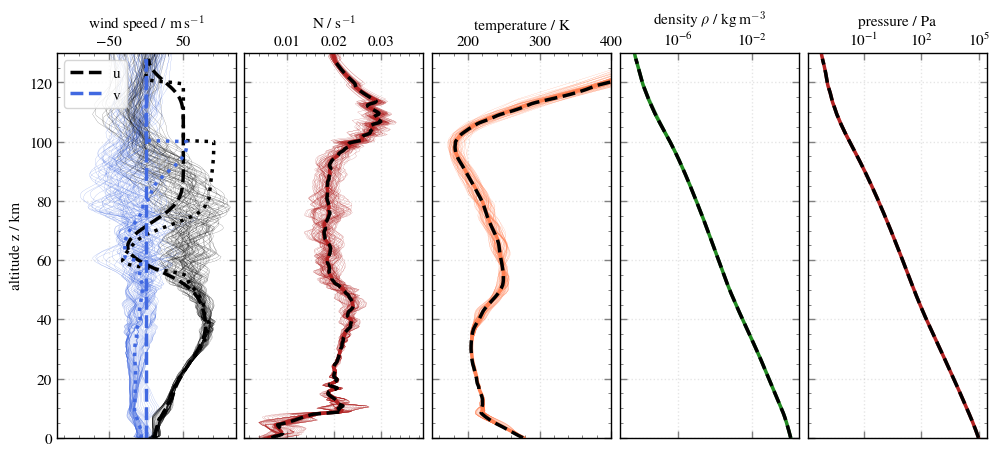

In [26]:
"""Vis env"""
# fig, ax = plt.subplots(1,1, figsize=(6,6), subplot_kw={'projection': ccrs.LambertConformal()})
fig, axes = plt.subplots(1,5, figsize=(12,5),sharey=True, gridspec_kw={"wspace": 0.05, "hspace": 0.05})
ax_wind  = axes[0]
ax_n     = axes[1]
ax_t     = axes[2]
ax_rho   = axes[3]
ax_p     = axes[4]

# ax.set_aspect("equal", adjustable='datalim')
"""Wind"""
lws = 0.1
lwl = 2.5
cu = "black"
cv = "royalblue"
for t in range(len(ds.time)):
    ax_wind.plot(ds["u"][t], ds["level"]/1000, lw=lws, color=cu)
    ax_wind.plot(ds["v"][t], ds["level"]/1000, lw=lws, color=cv)
# ax_wind.plot(dsm["u"], dsm["level"]/1000, lw=lwl, color="royalblue", label="u")
# ax_wind.plot(dsm["v"], dsm["level"]/1000, lw=lwl, color="skyblue", label="v")
ax_wind.plot(uphase0, levels/1000, lw=lwl, ls='--', color=cu, label="u")
ax_wind.plot(uphase1, levels/1000, lw=lwl, ls='dotted', color=cu)
ax_wind.plot(vphase0, levels/1000, lw=lwl, ls='--', color=cv, label="v")
ax_wind.plot(vphase1, levels/1000, lw=lwl, ls='dotted', color=cv)
ax_wind.legend(loc="upper left")

ax_wind.set_xlabel("wind speed / m$\,$s$^{-1}$")
ax_wind.set_ylabel("altitude z / km")
ax_wind.set_xlim([-120,120])
ax_wind.set_xticks([-50,50])
ax_wind.set_ylim([0,130])
ax_wind.xaxis.set_label_position('top')
ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
ax_wind.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_wind.grid()


"""N"""
for t in range(len(ds.time)):
    ax_n.plot(ds["N"][t], ds["level"]/1000, lw=lws, color="firebrick")
ax_n.plot(dsm["N"], dsm["level"]/1000, lw=lwl, color="firebrick")
ax_n.plot(N, levels/1000, lw=lwl, ls='--', color="black")
ax_n.set_xlabel("N / s$^{-1}$")
ax_n.set_xlim([0.001,0.039])

ax_n.xaxis.set_label_position('top')
ax_n.xaxis.set_minor_locator(AutoMinorLocator())
ax_n.yaxis.set_minor_locator(AutoMinorLocator())
ax_n.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_n.grid()

"""T"""
for t in range(len(ds.time)):
    ax_t.plot(ds["t"][t], ds["level"]/1000, lw=lws, color="coral")
ax_t.plot(dsm["t"], dsm["level"]/1000, lw=lwl, color="coral")
ax_t.plot(temp, levels/1000, lw=lwl, ls='--', color="black")

ax_t.set_xlabel("temperature / K")
ax_t.set_xlim(150,400)

ax_t.xaxis.set_label_position('top')
ax_t.xaxis.set_minor_locator(AutoMinorLocator())
ax_t.yaxis.set_minor_locator(AutoMinorLocator())
ax_t.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_t.grid()


"""Rho"""
for t in range(len(ds.time)):
    ax_rho.plot(ds["rho"][t], ds["level"]/1000, lw=lws, color="forestgreen")
ax_rho.plot(dsm["rho"], dsm["level"]/1000, lw=lwl, color="forestgreen")
ax_rho.plot(rho, levels/1000, lw=lwl, ls='--', color="black")
ax_rho.set_xlabel("density $\\rho$ / kg$\,$m$^{-3}$")
ax_rho.set_xscale('log')

ax_rho.xaxis.set_label_position('top')
ax_rho.xaxis.set_minor_locator(AutoMinorLocator())
ax_rho.yaxis.set_minor_locator(AutoMinorLocator())
ax_rho.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_rho.grid()

"""Pressure / Theta"""
for t in range(len(ds.time)):
    ax_p.plot(ds["p"][t], ds["level"]/1000, lw=lws, color="firebrick")
ax_p.plot(dsm["p"], dsm["level"]/1000, lw=lwl, color="firebrick")
ax_p.plot(p, levels/1000, lw=lwl, ls='--', color="black")
# ax_p.set_xlabel("$\Theta$ / K")
ax_p.set_xlabel("pressure / Pa")
# ax_p.set_xticks([2500,5000,7500])
ax_p.set_xscale('log')


ax_p.xaxis.set_label_position('top')
ax_p.xaxis.set_minor_locator(AutoMinorLocator())
ax_p.yaxis.set_minor_locator(AutoMinorLocator())
ax_p.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_p.grid()


"""Save figure"""
fig_name = "eulag_env.png"
fig.savefig(os.path.join(output_folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'

In [27]:
"""Create NETCDF"""
ds = xr.Dataset(
    {
        'u': (['level'], uphase0),
        'v': (['level'], vphase0),
        'th': (['level'], th),
        'rho': (['level'], rho),
    },
    coords={
        'level': levels
    }
)

# fname = "jawara_idealized_400m_l321.nc"
fname = "jawara_ideal_p01_400m_l321.nc"
# fname = "jawara_180522T10_400m_l321.nc"
ds.to_netcdf(os.path.join("./data/envs", fname), format='NETCDF3_64BIT') # format='NETCDF3_64BIT', engine='h5netcdf'

In [ ]:
"""Create NETCDF for PMAP"""
ds = xr.Dataset(
    {
        'u': (['level'], u),
        'v': (['level'], v),
        'th': (['level'], th),
        'rho': (['level'], rho),
    },
    coords={
        'level': levels
    }
)

fname = "era5_2018_06_17_tide_400m_l321.nc"
ds.to_netcdf(os.path.join("./data/envs", fname), format='NETCDF3_64BIT') # format='NETCDF3_64BIT', engine='h5netcdf'